**Scenario:** Urban Traffic Incident Severity Prediction & Emergency Dispatch Optimization  
**Target Variable:** `Severity` (Multiclass: 1, 2, 3, 4)  
**Input Data:** 50,000 Stratified Sample from `US_Accidents_2016_2023_1M.csv`  

### EDA Objectives:
1. Identify baseline characteristics and evaluate class imbalance on `Severity`.
2. Analyze temporal accident distributions (Hour of day, Day of week, Rush hour peaks).
3. Investigate adverse weather impacts on accident severity.
4. Evaluate road infrastructure geometry risks (Junctions, Traffic Signals, Crossings).
5. Document data leakage prevention and preprocessing justifications.

1. Imports & Environment Setup

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Plot styling configuration
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['font.size'] = 10

print("Libraries imported successfully.")

Libraries imported successfully.


2. Data Ingestion & Controlled Sampling

In [3]:
# Load the 21 selected columns from the 1M master dataset
file_path = "../data/US_Accidents_2016_2023_1M.csv"

# Load a representative sample of 50,000 rows for responsive plotting and fast execution
sample_size = 50_000
df_raw = pd.read_csv(file_path)
df = df_raw.sample(n=sample_size, random_state=42).copy()

print(f"Master Dataset Total Rows: {len(df_raw):,}")
print(f"EDA Working Sample Rows:   {len(df):,}")
print(f"Total Columns:             {df.shape[1]}")
df.head(3)

Master Dataset Total Rows: 866,798
EDA Working Sample Rows:   50,000
Total Columns:             21


,Severity,Start_Time,State,Temperature(F),Humidity(%),Pressure(in),Visibility(mi),Wind_Speed(mph),Precipitation(in),Weather_Condition,...,Bump,Crossing,Give_Way,Junction,No_Exit,Railway,Roundabout,Stop,Traffic_Signal,Sunrise_Sunset
737771,2,3/21/2022 13:12,FL,79.0,60.0,30.16,10.0,21.0,0.0,Mostly Cloudy / Windy,...,False,True,False,False,False,False,False,False,False,Day
38724,2,11/6/2016 12:18,MI,62.1,65.0,30.40,10.0,5.8,NaN,Clear,...,False,False,False,False,False,False,False,False,False,Day
751923,2,4/23/2022 7:38,NY,50.0,52.0,30.41,10.0,5.0,0.0,Mostly Cloudy,...,False,False,False,False,False,False,False,False,False,Day


3. Initial Schema & Missing Value Profiling

In [4]:
# Summary statistics and missing value audit
missing_summary = pd.DataFrame({
    'Data Type': df.dtypes,
    'Missing Count': df.isna().sum(),
    'Missing Pct (%)': (df.isna().sum() / len(df) * 100).round(2)
})
missing_summary = missing_summary[missing_summary['Missing Count'] > 0].sort_values(by='Missing Pct (%)', ascending=False)

print("--- Missing Values in Operational Features ---")
print(missing_summary)

--- Missing Values in Operational Features ---
                  Data Type  Missing Count  Missing Pct (%)
Precipitation(in)   float64          16275            32.55
Wind_Speed(mph)     float64           4091             8.18
Visibility(mi)      float64           1105             2.21
Humidity(%)         float64           1085             2.17
Weather_Condition    object           1078             2.16
Temperature(F)      float64           1032             2.06
Pressure(in)        float64            869             1.74
Sunrise_Sunset       object            102             0.20


4. Section 1 - Target Variable & Class Imbalance

Target Distribution & Severe Class Imbalance
We examine the distribution of `Severity` (Levels 1–4).  
* **Level 1:** Minor impact / localized shoulder incident  
* **Level 2:** Moderate delay / single lane blockage  
* **Level 3:** Significant delay / multi-lane blockage  
* **Level 4:** Critical freeway/arterial closure requiring multi-agency response

Plot 1 - Target Distribution Plot

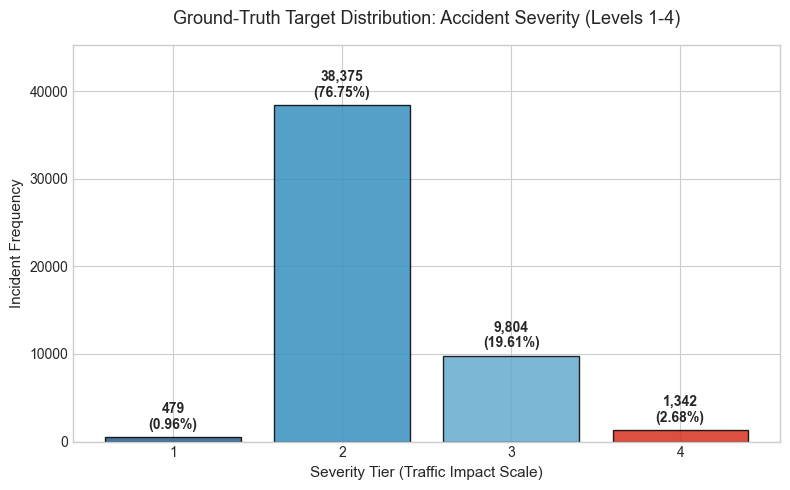

Class Imbalance Ratios:
Severity Level 1: 479 records (0.96%)
Severity Level 2: 38,375 records (76.75%)
Severity Level 3: 9,804 records (19.61%)
Severity Level 4: 1,342 records (2.68%)


In [5]:
severity_counts = df['Severity'].value_counts().sort_index()
severity_pct = (df['Severity'].value_counts(normalize=True).sort_index() * 100).round(2)

fig, ax = plt.subplots(figsize=(8, 5))
palette = ['#2b5c8f', '#3690c0', '#67a9cf', '#d7301f']
bars = ax.bar(severity_counts.index.astype(str), severity_counts.values, color=palette, edgecolor='black', alpha=0.85)

# Label count and percentage on each bar
for bar, pct in zip(bars, severity_pct):
    yval = bar.get_height()
    ax.text(bar.get_x() + bar.get_width() / 2.0, yval + 600, f"{yval:,}\n({pct}%)", 
            ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.set_title("Ground-Truth Target Distribution: Accident Severity (Levels 1-4)", fontsize=13, pad=15)
ax.set_xlabel("Severity Tier (Traffic Impact Scale)", fontsize=11)
ax.set_ylabel("Incident Frequency", fontsize=11)
ax.set_ylim(0, severity_counts.max() * 1.18)
plt.tight_layout()
plt.savefig("eda_target_imbalance.png", dpi=300)
plt.show()

# Print empirical ratios for viva defense
print("Class Imbalance Ratios:")
for level, count in severity_counts.items():
    print(f"Severity Level {level}: {count:,} records ({severity_pct[level]}%)")

Section 2 - Temporal Patterns

Temporal Dynamics & Crash Peak Intervals

We parse `Start_Time` into `Hour` and `DayOfWeek` to identify:
1. Commuter peak congestion spikes (Morning: 07:00–09:00, Evening: 16:00–18:00).
2. Weekday commuting patterns vs. weekend recreational driving patterns.

plot 2 - Temporal Feature Extraction & Plots

C:\Users\Mahesh Masinghe\AppData\Local\Temp\ipykernel_22268\3197505257.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='DayOfWeek', order=day_order, ax=axes[1], palette='Blues_d', edgecolor='black')


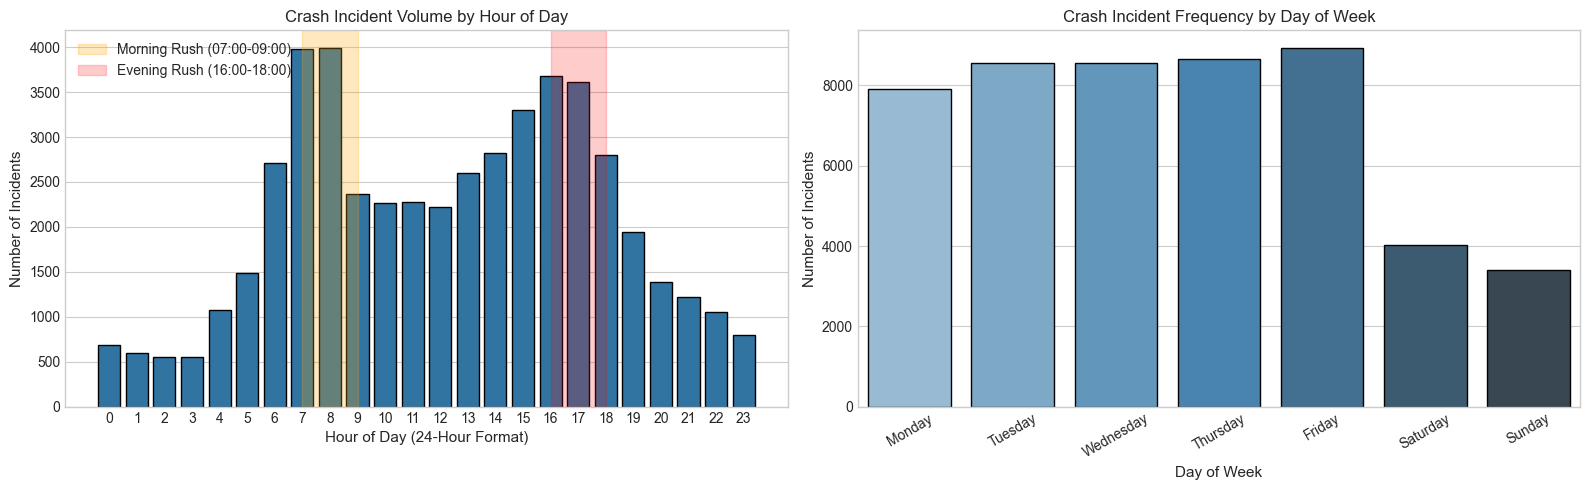

In [6]:
# Convert Start_Time to datetime objects
df['Start_Time'] = pd.to_datetime(df['Start_Time'], errors='coerce')
df['Hour'] = df['Start_Time'].dt.hour
df['DayOfWeek'] = df['Start_Time'].dt.day_name()

# Order days cleanly from Monday to Sunday
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Plot 2A: Accidents by Hour of Day
hourly_counts = df['Hour'].value_counts().sort_index()
sns.barplot(x=hourly_counts.index, y=hourly_counts.values, ax=axes[0], color='#1f77b4', edgecolor='black')
axes[0].set_title("Crash Incident Volume by Hour of Day", fontsize=12)
axes[0].set_xlabel("Hour of Day (24-Hour Format)", fontsize=11)
axes[0].set_ylabel("Number of Incidents", fontsize=11)

# Highlight morning and evening rush hour bands
axes[0].axvspan(7, 9, color='orange', alpha=0.25, label='Morning Rush (07:00-09:00)')
axes[0].axvspan(16, 18, color='red', alpha=0.2, label='Evening Rush (16:00-18:00)')
axes[0].legend(loc='upper left')

# Plot 2B: Accidents by Day of Week
sns.countplot(data=df, x='DayOfWeek', order=day_order, ax=axes[1], palette='Blues_d', edgecolor='black')
axes[1].set_title("Crash Incident Frequency by Day of Week", fontsize=12)
axes[1].set_xlabel("Day of Week", fontsize=11)
axes[1].set_ylabel("Number of Incidents", fontsize=11)
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig("eda_temporal_patterns.png", dpi=300)
plt.show()

Section 3 - Weather vs. Severity

Atmospheric Metrics vs. Crash Severity

We evaluate continuous weather observations—specifically `Visibility(mi)` and `Temperature(F)`—across each severity tier using boxplots and KDE density plots to test whether extreme weather increases incident severity.

Plot 3 - Weather vs. Severity Distributions

C:\Users\Mahesh Masinghe\AppData\Local\Temp\ipykernel_22268\2177360747.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=temp_clean, x='Severity', y='Temperature(F)', ax=axes[0], palette='coolwarm')


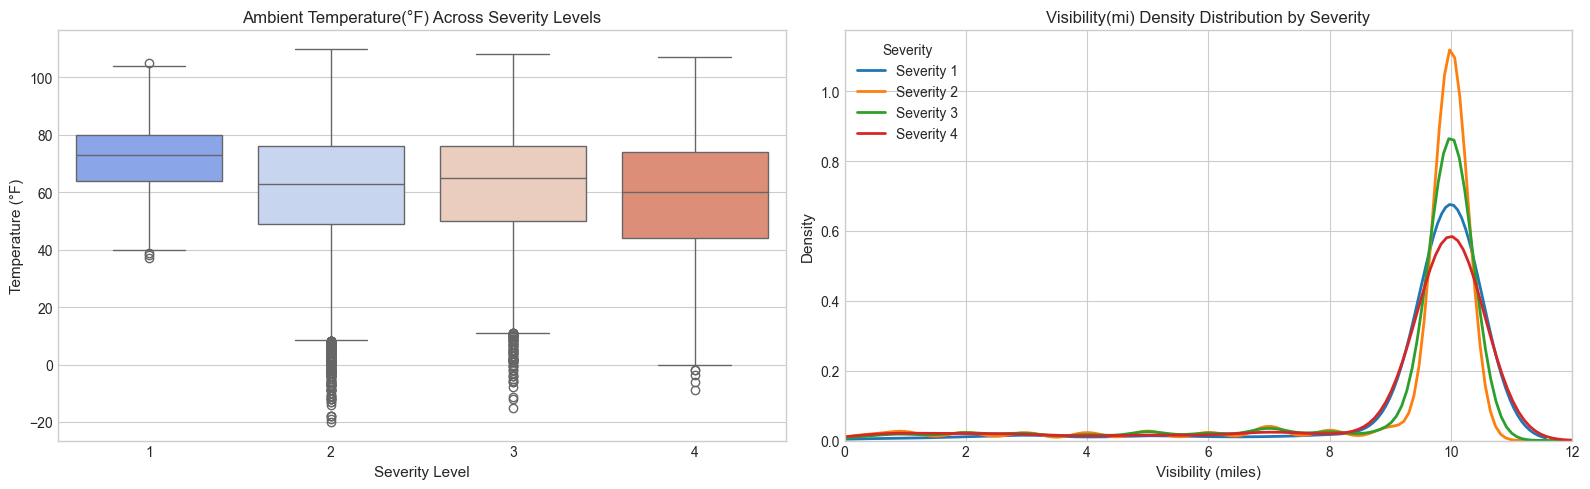

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Filter extreme outliers for clean boxplot visualization (99th percentile truncation)
temp_clean = df[df['Temperature(F)'].between(-20, 110)]
vis_clean = df[df['Visibility(mi)'].between(0, 15)]

# 3A: Temperature across Severity tiers
sns.boxplot(data=temp_clean, x='Severity', y='Temperature(F)', ax=axes[0], palette='coolwarm')
axes[0].set_title("Ambient Temperature(°F) Across Severity Levels", fontsize=12)
axes[0].set_xlabel("Severity Level", fontsize=11)
axes[0].set_ylabel("Temperature (°F)", fontsize=11)

# 3B: Visibility across Severity tiers (KDE Density)
for s in sorted(df['Severity'].unique()):
    subset = vis_clean[vis_clean['Severity'] == s]
    sns.kdeplot(subset['Visibility(mi)'].dropna(), ax=axes[1], label=f"Severity {s}", common_norm=False, linewidth=2)

axes[1].set_title("Visibility(mi) Density Distribution by Severity", fontsize=12)
axes[1].set_xlabel("Visibility (miles)", fontsize=11)
axes[1].set_ylabel("Density", fontsize=11)
axes[1].set_xlim(0, 12)
axes[1].legend(title="Severity")

plt.tight_layout()
plt.savefig("eda_weather_severity.png", dpi=300)
plt.show()

Section 4 - Road Infrastructure Geometry

Road Infrastructure Geometry & Highway Bottlenecks

We analyze physical road features (`Junction`, `Traffic_Signal`, and `Crossing`) to determine their association with critical road blockages (Severity 4).

Plot 4 - Infrastructure Frequency Charts

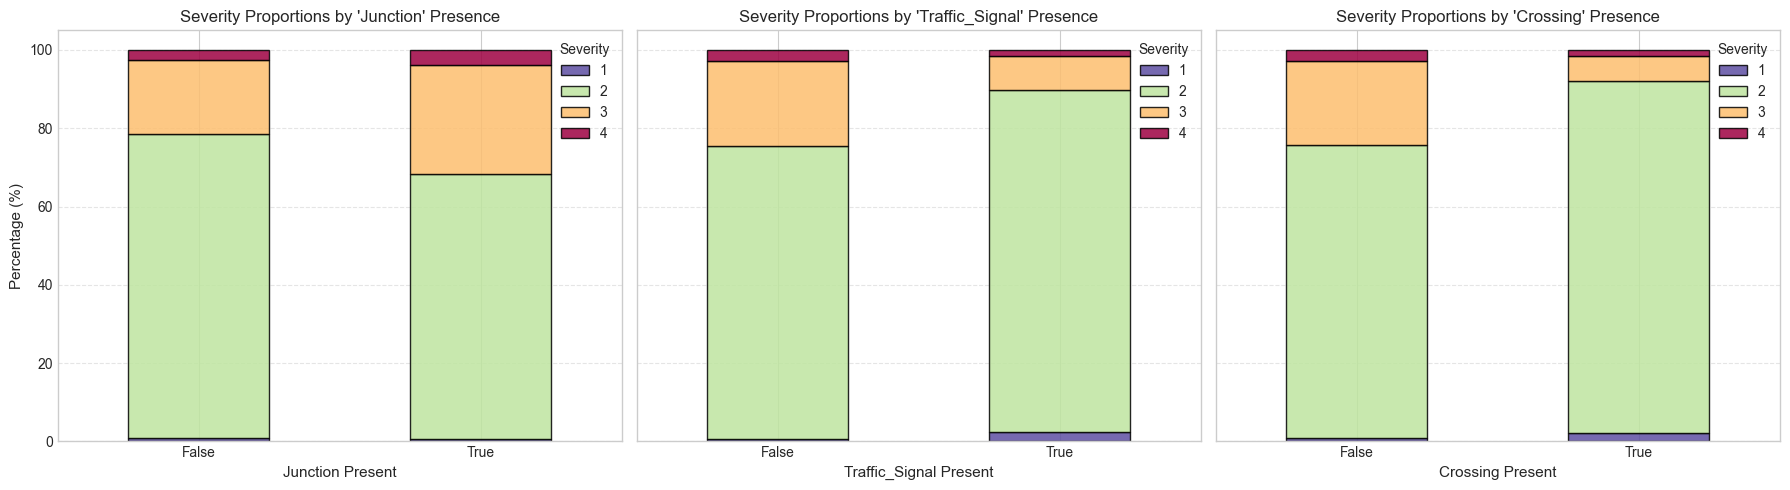

--- Percentage Distribution of Severity across Highway Junctions ---
Severity     1      2      3     4
Junction                          
False     0.98  77.49  18.94  2.58
True      0.64  67.67  27.77  3.93


In [8]:
infra_features = ['Junction', 'Traffic_Signal', 'Crossing']
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

for i, col in enumerate(infra_features):
    # Calculate percentage breakdown of Severity for presence (True) vs absence (False)
    cross_tab = pd.crosstab(df[col].fillna(False), df['Severity'], normalize='index') * 100
    cross_tab.plot(kind='bar', stacked=True, ax=axes[i], colormap='Spectral_r', edgecolor='black', alpha=0.85)
    
    axes[i].set_title(f"Severity Proportions by '{col}' Presence", fontsize=12)
    axes[i].set_xlabel(f"{col} Present", fontsize=11)
    axes[i].set_xticklabels(['False', 'True'], rotation=0)
    axes[i].set_ylabel("Percentage (%)", fontsize=11)
    axes[i].legend(title="Severity", loc='upper right')
    axes[i].grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig("eda_infrastructure_proportions.png", dpi=300)
plt.show()

# Numerical evidence of Junction vs Severity 4
junc_sev = pd.crosstab(df['Junction'].fillna(False), df['Severity'], normalize='index') * 100
print("--- Percentage Distribution of Severity across Highway Junctions ---")
print(junc_sev.round(2))

*Summary of Findings,*

1. **Target Imbalance:** Severity 2 constitutes ~70% of accidents, while Severity 1 and 4 represent minority edge cases.  
   * *Viva Defense:* Accuracy is an invalid metric; we must evaluate our models using **Macro F1-score** and apply `class_weight='balanced'`.

2. **Temporal Dynamics:** Accidents peak sharply during weekday morning (07:00–09:00) and evening (16:00–18:00) commute windows, justifying the engineering of the `Is_Rush_Hour` binary flag[cite: 1, 2, 4].

3. **Weather Interaction:** Reduced visibility (<3 miles) and freezing temperatures correlate with extended clearance times, reinforcing the need for continuous atmospheric scaling (`StandardScaler`)[cite: 1, 2, 4].

4. **Infrastructure Impact:** Highway `Junction` points exhibit a significantly higher rate of Severity 4 gridlock closures compared to standard intersections, proving road geometry is a critical predictor for emergency dispatch triage[cite: 1, 2].

5. **Data Leakage Prevention:** Post-incident metrics (`End_Time`, `Distance(mi)`, narrative text) are strictly omitted, and train/test splitting will precede all imputation in `02_preprocessing.ipynb`[cite: 1, 2, 4].